In [ ]:
import argparse
import ast
import json
import math
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
def parse_json_arrays_from_text(text: str):
    """
    Robustly parse JSON-like arrays from a log file.

    The log may contain many fragments like:
    [{"step": 1, ...}, {"step": 2, ...}]

    This function scans the whole text and tries to decode every top-level list.
    It first uses json.JSONDecoder, and falls back to ast.literal_eval for
    slightly non-standard Python-like literals.
    """
    arrays = []
    i = 0
    n = len(text)
    decoder = json.JSONDecoder()

    while i < n:
        start = text.find("[", i)
        if start == -1:
            break

        # Try standard JSON decoding from this position.
        try:
            obj, end = decoder.raw_decode(text[start:])
            if isinstance(obj, list):
                arrays.append(obj)
                i = start + end
                continue
        except Exception:
            pass

        # Fallback: bracket matching + ast.literal_eval.
        depth = 0
        in_str = False
        escape = False
        quote_char = None
        end_pos = None

        for j in range(start, n):
            ch = text[j]

            if in_str:
                if escape:
                    escape = False
                elif ch == "\\":
                    escape = True
                elif ch == quote_char:
                    in_str = False
                continue

            if ch in ("'", '"'):
                in_str = True
                quote_char = ch
            elif ch == "[":
                depth += 1
            elif ch == "]":
                depth -= 1
                if depth == 0:
                    end_pos = j + 1
                    break

        if end_pos is None:
            # No complete array found; stop scanning.
            break

        chunk = text[start:end_pos]
        try:
            obj = ast.literal_eval(chunk)
            if isinstance(obj, list):
                arrays.append(obj)
        except Exception:
            # Ignore this malformed array.
            pass

        i = end_pos

    return arrays


def normalize_token_str(token_str):
    """
    Make token string readable on plots.
    """
    if token_str is None:
        return ""

    s = str(token_str)

    # Visualize whitespace-like tokens.
    if s == " ":
        return "<space>"
    if s == "\n":
        return "<newline>"
    if s == "\t":
        return "<tab>"

    # Avoid extremely long labels.
    s = s.replace("\n", "\\n").replace("\t", "\\t")
    if len(s) > 18:
        s = s[:15] + "..."

    return s


def evenly_sample_df(df: pd.DataFrame, n: int) -> pd.DataFrame:
    """
    Evenly sample n rows from a sorted dataframe to show trend.
    If n >= len(df), return full df.
    """
    if n >= len(df):
        return df.copy()

    idx = [round(i * (len(df) - 1) / (n - 1)) for i in range(n)]
    return df.iloc[idx].copy()


def collect_records(arrays):
    """
    Convert decoded arrays into records.

    Each JSON array is treated as one generation/sample trajectory.
    A step is considered parallel if more than one token is decoded at that step
    within the same trajectory.
    """
    records = []

    for traj_id, arr in enumerate(arrays):
        entries = [x for x in arr if isinstance(x, dict)]

        # Count how many tokens are decoded in each step of this trajectory.
        step_counts = Counter()
        for e in entries:
            if "step" in e:
                step_counts[e["step"]] += 1

        for e in entries:
            try:
                step = int(e["step"])
                confidence = float(e.get("confidence", e.get("step_prob")))
                token_id = int(e["token_id"])
                token_str = str(e.get("token_str", ""))
            except Exception:
                continue

            is_parallel = step_counts[step] > 1

            records.append(
                {
                    "traj_id": traj_id,
                    "step": step,
                    "position": e.get("position", None),
                    "confidence": confidence,
                    "token_id": token_id,
                    "token_str": token_str,
                    "is_parallel": is_parallel,
                    "tokens_in_same_step": step_counts[step],
                }
            )

    return records


def aggregate_top_tokens(records, top_k=100):
    """
    Aggregate statistics for top-k most frequent token IDs.
    """
    df = pd.DataFrame(records)
    if df.empty:
        raise ValueError("No valid decoding records found in the log.")

    # Token frequency by token_id.
    freq = df["token_id"].value_counts()
    top_ids = set(freq.head(top_k).index.tolist())

    df_top = df[df["token_id"].isin(top_ids)].copy()

    grouped = (
        df_top.groupby("token_id")
        .agg(
            token_str=("token_str", lambda x: x.value_counts().index[0]),
            freq=("token_id", "size"),
            mean_confidence=("confidence", "mean"),
            median_confidence=("confidence", "median"),
            min_confidence=("confidence", "min"),
            max_confidence=("confidence", "max"),
            parallel_ratio=("is_parallel", "mean"),
            avg_tokens_in_same_step=("tokens_in_same_step", "mean"),
        )
        .reset_index()
    )

    grouped["token_label"] = grouped.apply(
        lambda row: f"{normalize_token_str(row['token_str'])}\n({row['token_id']})",
        axis=1,
    )

    return grouped


def plot_bar(df, x_col, y_col, title, ylabel, output_path, ylim=None):
    """
    Plot a simple bar chart.
    """
    plt.figure(figsize=(max(10, len(df) * 0.45), 5))
    plt.bar(range(len(df)), df[y_col].values)
    plt.xticks(range(len(df)), df[x_col].values, rotation=70, ha="right", fontsize=8)
    plt.ylabel(ylabel)
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.tight_layout()
    plt.show()
    # plt.savefig(output_path, dpi=300)
    # plt.close()



In [ ]:
from pathlib import Path
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image


# =========================
# 你只需要改这里
# =========================
log_file = "/Users/mc03002/Documents/soar_exp/data/gsm8k-len256_ns4_adaptive_parallel.log"   # 改成你的 log 路径
tokenizer_json_path = "/Users/mc03002/Documents/Prophet/gsm8k_token_analysis_t09/tokenizer.json"
out_dir = "gsm8k_token_analysis_t09_v2"

top_k = 500        # 先取最高频 top-k token 做统计
top_freq_n = 10    # 图1：最高频 token 数量
# =========================


def load_token_id_to_str_from_tokenizer_json(tokenizer_path):
    """
    Build token_id -> token_str mapping from HuggingFace tokenizer.json.

    Supports:
    - model.vocab: token_str -> token_id
    - added_tokens: list of {"id": ..., "content": ...}
    """
    tokenizer_path = Path(tokenizer_path)
    with tokenizer_path.open("r", encoding="utf-8") as f:
        tok = json.load(f)

    id_to_token = {}

    # BPE vocab: token_str -> token_id
    vocab = tok.get("model", {}).get("vocab", {})
    for token_str, token_id in vocab.items():
        try:
            id_to_token[int(token_id)] = token_str
        except Exception:
            pass

    # Added tokens
    for item in tok.get("added_tokens", []):
        try:
            token_id = int(item["id"])
            content = item["content"]
            id_to_token[token_id] = content
        except Exception:
            pass

    return id_to_token


def pretty_token_str(token_str):
    """
    Make tokenizer tokens readable for plots.

    Notes:
    - Some BPE tokenizers use Ġ to indicate leading space.
    - Some use Ċ for newline.
    - We keep visibility of whitespace but make it readable.
    """
    if token_str is None:
        return "<unk>"

    s = str(token_str)

    # Common BPE visual markers
    s = s.replace("Ġ", "▁")   # leading space marker
    s = s.replace("Ċ", "\\n")
    s = s.replace("ĉ", "\\t")

    if s == " ":
        return "<space>"
    if s == "\n":
        return "<newline>"
    if s == "\t":
        return "<tab>"
    if s == "":
        return "<empty>"

    s = s.replace("\n", "\\n").replace("\t", "\\t")

    if len(s) > 18:
        s = s[:15] + "..."

    return s


def remap_token_strings_in_records(records, id_to_token):
    """
    Replace or fill token_str using tokenizer.json mapping.

    We always prefer tokenizer mapping if available, because log token_str
    may have failed mapping or may be post-processed.
    """
    new_records = []

    for r in records:
        r = dict(r)
        token_id = int(r["token_id"])

        if token_id in id_to_token:
            r["token_str_raw"] = r.get("token_str", "")
            r["token_str"] = id_to_token[token_id]
            r["token_str_source"] = "tokenizer_json"
        else:
            r["token_str_raw"] = r.get("token_str", "")
            r["token_str_source"] = "log"

        new_records.append(r)

    return new_records


def aggregate_top_tokens_with_remap(records, top_k=100):
    """
    Aggregate top-k frequent tokens after token_str remapping.
    """
    df = pd.DataFrame(records)
    if df.empty:
        raise ValueError("No valid decoding records found.")

    freq = df["token_id"].value_counts()
    top_ids = set(freq.head(top_k).index.tolist())
    df_top = df[df["token_id"].isin(top_ids)].copy()

    grouped = (
        df_top.groupby("token_id")
        .agg(
            token_str=("token_str", lambda x: x.value_counts().index[0]),
            freq=("token_id", "size"),
            mean_confidence=("confidence", "mean"),
            median_confidence=("confidence", "median"),
            min_confidence=("confidence", "min"),
            max_confidence=("confidence", "max"),
            parallel_ratio=("is_parallel", "mean"),
            avg_tokens_in_same_step=("tokens_in_same_step", "mean"),
        )
        .reset_index()
    )

    grouped["token_label"] = grouped.apply(
        lambda row: f"{pretty_token_str(row['token_str'])}\n({row['token_id']})",
        axis=1,
    )

    return grouped


def plot_conf_and_parallel_same_fig(df, title, output_path):
    """
    Draw mean confidence and parallel decoding ratio in one bar chart.

    Both metrics are in [0, 1], so we can put them on the same y-axis.
    """
    if df.empty:
        print(f"[WARN] Empty dataframe for {title}, skip plotting.")
        return

    x = range(len(df))
    width = 0.38

    plt.figure(figsize=(max(8, len(df) * 0.7), 5))

    plt.bar(
        [i - width / 2 for i in x],
        df["mean_confidence"].values,
        width=width,
        label="Mean confidence",
    )

    plt.bar(
        [i + width / 2 for i in x],
        df["parallel_ratio"].values,
        width=width,
        label="Parallel decoding ratio",
    )

    plt.xticks(x, df["token_label"].values, rotation=60, ha="right", fontsize=9)
    plt.ylim(0, 1.05)
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.close()


def select_digit_tokens(stats):
    """
    Select tokens corresponding to digits 0-9.

    We support raw tokenizer token forms:
    - "0", "1", ...
    - "Ġ0", "Ġ1", ...
    - "▁0" after pretty conversion is not used here; raw token_str is used.
    """
    digit_rows = []

    for _, row in stats.iterrows():
        raw = str(row["token_str"])
        normalized = raw.replace("Ġ", "").strip()

        if normalized in [str(i) for i in range(10)]:
            digit_rows.append(row)

    if not digit_rows:
        return pd.DataFrame(columns=stats.columns)

    digit_df = pd.DataFrame(digit_rows).copy()

    # Sort by actual digit order if possible.
    def digit_key(s):
        raw = str(s).replace("Ġ", "").strip()
        try:
            return int(raw)
        except Exception:
            return 999

    digit_df["digit_order"] = digit_df["token_str"].apply(digit_key)
    digit_df = digit_df.sort_values("digit_order").drop(columns=["digit_order"])

    return digit_df


def select_punctuation_tokens(stats):
    """
    Select common punctuation tokens.
    """
    punct_set = {
        ".", ",", ":", ";", "!", "?", 
        "(", ")", "[", "]", "{", "}",
        "+", "-", "*", "/", "=", 
        "'", '"'
    }

    rows = []
    for _, row in stats.iterrows():
        raw = str(row["token_str"])
        normalized = raw.replace("Ġ", "").strip()

        if normalized in punct_set:
            rows.append(row)

    if not rows:
        return pd.DataFrame(columns=stats.columns)

    punct_df = pd.DataFrame(rows).copy()

    # Sort by frequency descending by default.
    punct_df = punct_df.sort_values("freq", ascending=False)

    return punct_df


# =========================
# Main notebook execution
# =========================

out_dir = Path(out_dir)
out_dir.mkdir(parents=True, exist_ok=True)

print("[INFO] Loading tokenizer.json...")
id_to_token = load_token_id_to_str_from_tokenizer_json(tokenizer_json_path)
print(f"[INFO] Loaded {len(id_to_token)} token id mappings.")

print("[INFO] Reading log...")
text = Path(log_file).read_text(encoding="utf-8", errors="ignore")

arrays = parse_json_arrays_from_text(text)
print(f"[INFO] Parsed {len(arrays)} JSON-like trajectory arrays.")

records = collect_records(arrays)
print(f"[INFO] Collected {len(records)} token decoding records.")

if len(records) == 0:
    raise RuntimeError("No valid records found. Please check the log format.")

records = remap_token_strings_in_records(records, id_to_token)

stats = aggregate_top_tokens_with_remap(records, top_k=top_k)

# Save full statistics
stats_by_freq = stats.sort_values("freq", ascending=False).reset_index(drop=True)
stats_by_conf = stats.sort_values("mean_confidence", ascending=True).reset_index(drop=True)
stats_by_parallel = stats.sort_values("parallel_ratio", ascending=True).reset_index(drop=True)

stats_by_freq.to_csv(out_dir / "top_tokens_by_frequency_remapped.csv", index=False)
stats_by_conf.to_csv(out_dir / "top_tokens_sorted_by_mean_confidence_remapped.csv", index=False)
stats_by_parallel.to_csv(out_dir / "top_tokens_sorted_by_parallel_ratio_remapped.csv", index=False)

display(stats_by_freq.head(20))



In [ ]:
# =========================
# New grouped plotting:
# 4 categories × 5 tokens
# 1) lowest mean confidence
# 2) digits
# 3) math punctuation
# 4) highest mean confidence
# =========================

num_per_category = 5


def normalize_token_for_category(token_str):
    """
    Normalize tokenizer token string for category matching.
    Handles common BPE leading-space marker Ġ.
    """
    s = str(token_str)
    s = s.replace("Ġ", "").strip()
    return s


def pick_low_confidence_tokens(stats, k=5, used_ids=None):
    if used_ids is None:
        used_ids = set()

    df = stats[~stats["token_id"].isin(used_ids)].copy()
    df = df.sort_values("mean_confidence", ascending=True).head(k).copy()
    df["category"] = "Lowest confidence"
    return df


def pick_high_confidence_tokens(stats, k=5, used_ids=None):
    if used_ids is None:
        used_ids = set()

    df = stats[~stats["token_id"].isin(used_ids)].copy()
    df = df.sort_values("mean_confidence", ascending=False).head(k).copy()
    df["category"] = "Highest confidence"
    return df


def pick_digit_tokens_topfreq(stats, k=5, used_ids=None):
    """
    Pick digit tokens from top-k frequent token stats.
    If more than k digits exist, choose the most frequent k.
    """
    if used_ids is None:
        used_ids = set()

    digit_set = {str(i) for i in range(10)}
    rows = []

    for _, row in stats.iterrows():
        token_norm = normalize_token_for_category(row["token_str"])
        if token_norm in digit_set and row["token_id"] not in used_ids:
            rows.append(row)

    if len(rows) == 0:
        return pd.DataFrame(columns=list(stats.columns) + ["category"])

    df = pd.DataFrame(rows).copy()
    df = df.sort_values("freq", ascending=False).head(k).copy()
    df["category"] = "Digits"
    return df


def pick_math_punctuation_tokens_topfreq(stats, k=5, used_ids=None):
    """
    Pick math-related punctuation/symbol tokens from top-k frequent token stats.
    Choose the most frequent k.

    You can adjust this set depending on tokenizer and task.
    """
    if used_ids is None:
        used_ids = set()

    math_punct_set = {
        "+", "-", "*", "/", "=", 
        # ".", ",", ":", ";",
        # "(", ")", "[", "]",
        # "$", "%", 
        # "<", ">", 
    }

    rows = []

    for _, row in stats.iterrows():
        token_norm = normalize_token_for_category(row["token_str"])
        if token_norm in math_punct_set and row["token_id"] not in used_ids:
            rows.append(row)

    if len(rows) == 0:
        return pd.DataFrame(columns=list(stats.columns) + ["category"])

    df = pd.DataFrame(rows).copy()
    df = df.sort_values("freq", ascending=False).head(k).copy()
    df["category"] = "Math punctuation"
    return df


def build_grouped_token_selection(stats_by_freq, stats_by_conf, k=5, avoid_overlap=True):
    """
    Build selected tokens in the requested category order:
    1. Lowest confidence
    2. Digits
    3. Math punctuation
    4. Highest confidence

    If avoid_overlap=True, a token already selected by an earlier category
    will not be reused in later categories.
    """
    selected_parts = []
    used_ids = set()

    # 1. Lowest confidence
    low_df = pick_low_confidence_tokens(
        stats_by_conf, 
        k=k, 
        used_ids=used_ids if avoid_overlap else set()
    )
    selected_parts.append(low_df)
    if avoid_overlap:
        used_ids.update(low_df["token_id"].tolist())

    # 2. Digits
    digit_df = pick_digit_tokens_topfreq(
        stats_by_freq, 
        k=k, 
        used_ids=used_ids if avoid_overlap else set()
    )
    selected_parts.append(digit_df)
    if avoid_overlap and not digit_df.empty:
        used_ids.update(digit_df["token_id"].tolist())

    # 3. Math punctuation
    math_punct_df = pick_math_punctuation_tokens_topfreq(
        stats_by_freq, 
        k=k, 
        used_ids=used_ids if avoid_overlap else set()
    )
    selected_parts.append(math_punct_df)
    if avoid_overlap and not math_punct_df.empty:
        used_ids.update(math_punct_df["token_id"].tolist())

    # 4. Highest confidence
    high_df = pick_high_confidence_tokens(
        stats_by_conf, 
        k=k, 
        used_ids=used_ids if avoid_overlap else set()
    )
    selected_parts.append(high_df)

    selected = pd.concat(selected_parts, ignore_index=True)

    # Fix category order
    category_order = [
        "Lowest confidence",
        "Digits",
        "Math punctuation",
        "Highest confidence",
    ]
    selected["category"] = pd.Categorical(
        selected["category"],
        categories=category_order,
        ordered=True,
    )

    selected = selected.sort_values(["category"]).reset_index(drop=True)

    # Build plot label with category and token
    selected["plot_label"] = selected.apply(
        lambda row: f"{pretty_token_str(row['token_str'])}\n({row['token_id']})",
        axis=1,
    )

    return selected


def plot_grouped_single_metric(
    df,
    metric_col,
    ylabel,
    title,
    output_path,
    ylim=(0, 1.05),
):
    """
    Plot a single metric bar chart with category ordering.
    Mean confidence and parallel ratio should be plotted separately.
    """
    if df.empty:
        print(f"[WARN] Empty dataframe for {title}, skip plotting.")
        return

    x = list(range(len(df)))

    plt.figure(figsize=(max(12, len(df) * 0.55), 5.2))
    plt.bar(x, df[metric_col].values)

    plt.xticks(x, df["plot_label"].values, rotation=60, ha="right", fontsize=8)
    plt.ylabel(ylabel)
    plt.title(title)

    if ylim is not None:
        plt.ylim(*ylim)

    # Add vertical separators and category labels
    category_names = df["category"].astype(str).tolist()
    boundaries = []
    prev = category_names[0]

    for idx, cat in enumerate(category_names):
        if cat != prev:
            boundaries.append(idx - 0.5)
            prev = cat

    for b in boundaries:
        plt.axvline(b, linestyle="--", linewidth=1)

    # Put category names above each group
    for cat in df["category"].cat.categories:
        cat_indices = [i for i, c in enumerate(category_names) if c == cat]
        if len(cat_indices) == 0:
            continue
        mid = (cat_indices[0] + cat_indices[-1]) / 2
        plt.text(
            mid,
            ylim[1] * 0.98 if ylim else max(df[metric_col].values) * 1.02,
            str(cat),
            ha="center",
            va="top",
            fontsize=9,
        )

    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.close()


# Build selected tokens from top_k frequent statistics.
# Note: stats_by_freq/stats_by_conf are already based on top_k frequent tokens.
grouped_selected = build_grouped_token_selection(
    stats_by_freq=stats_by_freq,
    stats_by_conf=stats_by_conf,
    k=num_per_category,
    avoid_overlap=True,
)

grouped_selected.to_csv(out_dir / "grouped_selected_tokens.csv", index=False)

display(grouped_selected[
    [
        "category",
        "token_id",
        "token_str",
        "freq",
        "mean_confidence",
        "parallel_ratio",
        "median_confidence",
        "avg_tokens_in_same_step",
    ]
])


# Figure A: mean confidence
plot_grouped_single_metric(
    grouped_selected,
    metric_col="mean_confidence",
    ylabel="Mean confidence",
    title=f"Mean Confidence by Token Category within Top-{top_k} Frequent Tokens",
    output_path=out_dir / "fig_grouped_mean_confidence.png",
    ylim=(0, 1.05),
)


# Figure B: parallel decoding ratio
plot_grouped_single_metric(
    grouped_selected,
    metric_col="parallel_ratio",
    ylabel="Parallel decoding ratio",
    title=f"Parallel Decoding Ratio by Token Category within Top-{top_k} Frequent Tokens",
    output_path=out_dir / "fig_grouped_parallel_ratio.png",
    ylim=(0, 1.05),
)


print(f"[DONE] Grouped plots saved to: {out_dir}")
print(f"  - {out_dir / 'grouped_selected_tokens.csv'}")
print(f"  - {out_dir / 'fig_grouped_mean_confidence.png'}")
print(f"  - {out_dir / 'fig_grouped_parallel_ratio.png'}")

display(Image(filename=str(out_dir / "fig_grouped_mean_confidence.png")))
display(Image(filename=str(out_dir / "fig_grouped_parallel_ratio.png")))

In [ ]:
from pathlib import Path
import json
import pandas as pd


# =========================
# 你只需要改这里
# =========================

# 可以是单个 log，也可以是多个 log
log_files = [
    "/Users/mc03002/Documents/soar_exp/data/gsm8k-len256_ns4_adaptive_parallel.log",
    # "/path/to/another.log",
]

out_dir = "token_threshold_stats"

# 低频 token 是否过滤
min_count = 20

# 是否对 threshold 做上下界截断
clip_threshold = True
tau_min = 0.0
tau_max = 1.0

# =========================


def load_records_from_logs(log_files):
    """
    Load decoding records from multiple log files.

    Requires these helper functions to be already defined:
    - parse_json_arrays_from_text
    - collect_records

    Each parsed record should contain:
    - token_id
    - confidence
    """
    all_records = []

    for log_file in log_files:
        log_path = Path(log_file)
        print(f"[INFO] Reading {log_path}")

        text = log_path.read_text(encoding="utf-8", errors="ignore")

        arrays = parse_json_arrays_from_text(text)
        print(f"  Parsed {len(arrays)} JSON-like trajectory arrays.")

        records = collect_records(arrays)
        print(f"  Collected {len(records)} token decoding records.")

        all_records.extend(records)

    print(f"[INFO] Total records: {len(all_records)}")
    return all_records


def build_token_quantile_thresholds(records, min_count=1, clip_threshold=True, tau_min=0.0, tau_max=1.0):
    """
    Compute p25, p50, p75 thresholds for each token_id.

    Returns:
    - stats_df
    - threshold_dicts:
        {
          "p25": {token_id: threshold},
          "p50": {token_id: threshold},
          "p75": {token_id: threshold},
          "mean": {token_id: threshold},
        }
    """
    df = pd.DataFrame(records)

    if df.empty:
        raise ValueError("No records found.")

    if "token_id" not in df.columns or "confidence" not in df.columns:
        raise ValueError("records must contain token_id and confidence fields.")

    df = df[["token_id", "confidence"]].copy()
    df["token_id"] = df["token_id"].astype(int)
    df["confidence"] = df["confidence"].astype(float)

    grouped = df.groupby("token_id")["confidence"]

    stats_df = grouped.agg(
        count="count",
        mean="mean",
        p05=lambda x: x.quantile(0.05),
        p10=lambda x: x.quantile(0.10),
        p15=lambda x: x.quantile(0.15),
        p25=lambda x: x.quantile(0.25),
        p50=lambda x: x.quantile(0.50),
        p75=lambda x: x.quantile(0.75),
        min_conf="min",
        max_conf="max",
    ).reset_index()

    # filter low-frequency tokens
    stats_df = stats_df[stats_df["count"] >= min_count].copy()

    if clip_threshold:
        for col in ["mean", "p05", "p10", "p15", "p25", "p50", "p75"]:
            stats_df[col] = stats_df[col].clip(lower=tau_min, upper=tau_max)

    threshold_dicts = {}

    for col in ["p05", "p10", "p15", "p25", "p50", "p75", "mean"]:
        threshold_dicts[col] = {
            str(int(row["token_id"])): float(row[col])
            for _, row in stats_df.iterrows()
        }

    return stats_df, threshold_dicts


def save_threshold_jsons(threshold_dicts, out_dir):
    """
    Save multiple JSON threshold files.
    Each file format:
      {token_id: threshold}
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    for name, threshold_dict in threshold_dicts.items():
        out_path = out_dir / f"token_threshold_{name}.json"
        with out_path.open("w", encoding="utf-8") as f:
            json.dump(threshold_dict, f, indent=2, ensure_ascii=False)

        print(f"[SAVED] {out_path}")


# =========================
# Run
# =========================

out_dir = Path(out_dir)
out_dir.mkdir(parents=True, exist_ok=True)

records = load_records_from_logs(log_files)

stats_df, threshold_dicts = build_token_quantile_thresholds(
    records,
    min_count=min_count,
    clip_threshold=clip_threshold,
    tau_min=tau_min,
    tau_max=tau_max,
)

# Save full CSV for inspection
stats_csv_path = out_dir / "token_confidence_quantile_stats.csv"
stats_df.sort_values("count", ascending=False).to_csv(stats_csv_path, index=False)
print(f"[SAVED] {stats_csv_path}")

# Save JSON threshold files
save_threshold_jsons(threshold_dicts, out_dir)

display(stats_df.sort_values("count", ascending=False).head(20))

样本的置信度直方图+与最终结果的对比

In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


def try_parse_json_object_from_line(line: str):
    """
    Try to parse a JSON object from a log line.

    Expected object format:
    {
        "selected_records": [...],
        "all_token_records": [...],
        "stats": {...}
    }
    """
    if '"all_token_records"' not in line:
        return None

    start = line.find("{")
    if start < 0:
        return None

    decoder = json.JSONDecoder()
    try:
        obj, end = decoder.raw_decode(line[start:])
        if isinstance(obj, dict) and "all_token_records" in obj and "selected_records" in obj:
            return obj
    except Exception:
        return None

    return None


def load_one_problem_trace(log_path, problem_index=0):
    """
    Stream the huge log file line by line.
    Return the problem_index-th JSON object that contains all_token_records.
    """
    log_path = Path(log_path)
    count = 0

    with log_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line_no, line in enumerate(f, start=1):
            obj = try_parse_json_object_from_line(line)
            if obj is None:
                continue

            if count == problem_index:
                print(f"[INFO] Found problem_index={problem_index} at line {line_no}")
                return obj

            count += 1

    raise ValueError(
        f"Could not find problem_index={problem_index}. "
        f"Only found {count} traces with all_token_records."
    )


def prepare_data(trace_obj):
    """
    Prepare:
    - df_all: dataframe from all_token_records
    - final_token_by_pos: final committed token for each generation position
    - commit_step_by_pos: the step when each generation position was committed
    - commit_conf_by_pos: confidence at commit step
    """
    selected_records = trace_obj["selected_records"]
    all_token_records = trace_obj["all_token_records"]

    df_all = pd.DataFrame(all_token_records)
    if df_all.empty:
        raise ValueError("all_token_records is empty.")

    # normalize dtypes
    for col in ["global_step", "local_step", "block", "position",
                "block_relative_position", "generation_relative_position", "token_id"]:
        if col in df_all.columns:
            df_all[col] = df_all[col].astype(int)

    df_all["confidence"] = df_all["confidence"].astype(float)

    # final token / commit step / commit confidence by generation position
    final_token_by_pos = {}
    commit_step_by_pos = {}
    commit_conf_by_pos = {}

    for r in selected_records:
        gen_pos = int(r["generation_relative_position"])
        final_token_by_pos[gen_pos] = int(r["token_id"])
        commit_step_by_pos[gen_pos] = int(r["global_step"])
        commit_conf_by_pos[gen_pos] = float(r["confidence"])

    # attach final token to df_all
    df_all["final_token_id"] = df_all["generation_relative_position"].map(final_token_by_pos)
    df_all["is_final_consistent"] = (
        df_all["final_token_id"].notna()
        & (df_all["token_id"] == df_all["final_token_id"].astype("Int64"))
    )

    return df_all, final_token_by_pos, commit_step_by_pos, commit_conf_by_pos


def map_requested_step_to_logged_step(step, zero_based=True):
    """
    Our logger uses global_step starting from 1.
    If zero_based=True:
        requested 0 -> logged 1
        requested 8 -> logged 9
    """
    return step + 1 if zero_based else step


def plot_confidence_for_one_problem(
    df_all,
    final_token_by_pos,
    commit_step_by_pos,
    commit_conf_by_pos,
    steps_to_plot,
    gen_length=256,
    zero_based_step_input=True,
    out_png=None,
    bar_width=0.82,
):
    """
    Plot full 0..255 positions for each requested step.

    Colors:
    - gray: already unmasked / committed before or at this step
    - green: current step record exists and current top-1 token == final token
    - red: current step record exists and current top-1 token != final token

    Notes:
    - Because the current logging only stores candidate confidences for the current block,
      only the current active block will have green/red bars.
    - Already committed positions are shown in gray using their commit confidence.
    - Future positions not yet active and not yet committed remain 0-height bars, but
      the x-axis still spans the full 0..255 range.
    """
    mapped_steps = [map_requested_step_to_logged_step(s, zero_based_step_input) for s in steps_to_plot]

    n = len(steps_to_plot)
    fig, axes = plt.subplots(
        n,
        1,
        figsize=(18, max(3, 2.4 * n)),
        sharex=True,
    )

    if n == 1:
        axes = [axes]

    all_positions = np.arange(gen_length)

    for ax, req_step, logged_step in zip(axes, steps_to_plot, mapped_steps):

        # initialize full arrays
        heights = np.zeros(gen_length, dtype=float)
        colors = np.array(["white"] * gen_length, dtype=object)  # default blank
        edgecolors = np.array(["white"] * gen_length, dtype=object)

        # 1) already committed positions -> gray
        for pos in range(gen_length):
            commit_step = commit_step_by_pos.get(pos, None)
            if commit_step is not None and commit_step <= logged_step:
                heights[pos] = commit_conf_by_pos.get(pos, 1.0)
                colors[pos] = "lightgray"
                edgecolors[pos] = "lightgray"

        # 2) current step active positions -> override with red/green + current confidence
        sub = df_all[df_all["global_step"] == logged_step].copy()
        sub = sub.sort_values("generation_relative_position")

        for _, row in sub.iterrows():
            pos = int(row["generation_relative_position"])
            if pos < 0 or pos >= gen_length:
                continue

            heights[pos] = float(row["confidence"])
            if bool(row["is_final_consistent"]):
                colors[pos] = "tab:green"
                edgecolors[pos] = "tab:green"
            else:
                colors[pos] = "tab:red"
                edgecolors[pos] = "tab:red"

        # 3) find the left boundary: the minimum position among currently undecoded tokens
        undecoded_positions = []
        for pos in range(gen_length):
            commit_step = commit_step_by_pos.get(pos, None)
            if commit_step is None or commit_step > logged_step:
                undecoded_positions.append(pos)

        min_undecoded_pos = min(undecoded_positions) if len(undecoded_positions) > 0 else None

        # draw bars
        ax.bar(
            all_positions,
            heights,
            width=bar_width,
            color=colors.tolist(),
            edgecolor=edgecolors.tolist(),
            linewidth=0.3,
        )

        # horizontal reference line at 0.90
        ax.axhline(0.90, color="royalblue", linestyle="--", linewidth=1.1, alpha=0.9)
        ax.text(
            gen_length - 3,
            0.905,
            "0.90",
            color="royalblue",
            fontsize=8,
            ha="right",
            va="bottom",
        )

        # vertical divider at left of the minimum undecoded position
        if min_undecoded_pos is not None:
            ax.axvline(
                min_undecoded_pos - 0.5,
                color="black",
                linestyle="--",
                linewidth=1.3,
            )
            ax.text(
                min_undecoded_pos,
                1.02,
                f"min undecoded = {min_undecoded_pos}",
                fontsize=8,
                ha="left",
                va="bottom",
                color="black",
            )

        # stats for title
        num_gray = np.sum(colors == "lightgray")
        num_green = np.sum(colors == "tab:green")
        num_red = np.sum(colors == "tab:red")

        ax.set_xlim(-1, gen_length)
        ax.set_ylim(0, 1.08)
        ax.set_ylabel("Confidence")
        ax.set_title(
            f"Problem {problem_index} | requested step={req_step} | logged global_step={logged_step} | "
            f"gray(committed)={num_gray}, green(match final)={num_green}, red(mismatch)={num_red}"
        )
        ax.grid(axis="y", alpha=0.25)

    axes[-1].set_xlabel("Generation-relative position (0-255)")
    axes[-1].set_xticks(list(range(0, gen_length + 1, 32)))

    legend_handles = [
        Patch(color="lightgray", label="Already unmasked / committed"),
        Patch(color="tab:green", label="Current top-1 matches final token"),
        Patch(color="tab:red", label="Current top-1 differs from final token"),
        Patch(facecolor="white", edgecolor="black", label="Dashed vertical line: leftmost undecoded position"),
        Patch(facecolor="white", edgecolor="royalblue", label="Blue dashed horizontal line: confidence = 0.90"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 1.01),
    )

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    if out_png is not None:
        out_path = Path(out_png)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        print(f"[SAVED] {out_path}")

    plt.show()

# =========================
# User config
# =========================
log_file = "/Users/mc03002/Documents/Prophet/logs/baseline-gsm8k_standard-len256-block32-4gpu.log"

# 第几个问题，0-based index
problem_index = 1

# 你想看的 decoding steps
# 如果 ZERO_BASED_STEP_INPUT=True，那么 step=0 会映射到日志里的 global_step=1
steps_to_plot = list(range(0, 256, 16))

ZERO_BASED_STEP_INPUT = True

out_png = f"figures/sample_confidence/confidence_by_position_problem{problem_index}.png"

gen_length = 256
prompt_len = None   # 可不填，这里用 generation_relative_position 即可
bar_width = 0.82
# =========================

# =========================
# Run
# =========================
trace_obj = load_one_problem_trace(log_file, problem_index=problem_index)

df_all, final_token_by_pos, commit_step_by_pos, commit_conf_by_pos = prepare_data(trace_obj)

print("[INFO] #selected_records =", len(trace_obj["selected_records"]))
print("[INFO] #all_token_records =", len(trace_obj["all_token_records"]))
print("[INFO] #final positions =", len(final_token_by_pos))
print("[INFO] global_step min/max =", df_all["global_step"].min(), df_all["global_step"].max())

plot_confidence_for_one_problem(
    df_all=df_all,
    final_token_by_pos=final_token_by_pos,
    commit_step_by_pos=commit_step_by_pos,
    commit_conf_by_pos=commit_conf_by_pos,
    steps_to_plot=steps_to_plot,
    gen_length=gen_length,
    zero_based_step_input=ZERO_BASED_STEP_INPUT,
    out_png=out_png,
    bar_width=bar_width,
)

更加细粒度的分析

In [46]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# Config
# =========================
log_file = "logs/gpqa_baseline_len256_block32.log"

# 读取多少个问题；None 表示全读，但大日志会很慢
max_problems = None

gen_length = 256
out_dir = Path("figures/final_consistency")
out_dir.mkdir(parents=True, exist_ok=True)

# confidence bins
bin_width = 0.1
bins = np.arange(0.0, 1.0 + bin_width, bin_width)

# 指定 token id
target_token_ids = [10, 18, 8752, 12032]
token_id_to_name = {
    10: "+",
    18: "3",
    8752: "Style",
    12032: "options",
}

# position bucket
num_pos_buckets = 8
# =========================


def try_parse_json_object_from_line(line: str):
    """
    Parse one JSON object containing:
      selected_records
      all_token_records
      stats
    """
    if '"all_token_records"' not in line:
        return None

    start = line.find("{")
    if start < 0:
        return None

    decoder = json.JSONDecoder()
    try:
        obj, _ = decoder.raw_decode(line[start:])
        if isinstance(obj, dict) and "all_token_records" in obj and "selected_records" in obj:
            return obj
    except Exception:
        return None

    return None


def iter_trace_objects(log_path, max_problems=None):
    """
    Stream huge log file line by line.
    """
    log_path = Path(log_path)
    count = 0

    with log_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line_no, line in enumerate(f, start=1):
            obj = try_parse_json_object_from_line(line)
            if obj is None:
                continue

            yield count, obj

            count += 1
            if max_problems is not None and count >= max_problems:
                break

    print(f"[INFO] Loaded {count} traces.")


def trace_to_dataframe(problem_idx, trace_obj):
    """
    Build dataframe with final-consistency labels.

    final_consistent = current top-1 token at this step equals final committed token at same position.
    """
    selected_records = trace_obj["selected_records"]
    all_token_records = trace_obj["all_token_records"]

    final_token_by_pos = {}
    commit_step_by_pos = {}

    for r in selected_records:
        gen_pos = int(r["generation_relative_position"])
        final_token_by_pos[gen_pos] = int(r["token_id"])
        commit_step_by_pos[gen_pos] = int(r["global_step"])

    df = pd.DataFrame(all_token_records)
    if df.empty:
        return df

    needed_cols = [
        "global_step",
        "block",
        "generation_relative_position",
        "confidence",
        "token_id",
    ]
    for col in needed_cols:
        if col not in df.columns:
            raise ValueError(f"Missing column {col} in all_token_records.")

    df["problem_idx"] = problem_idx
    df["global_step"] = df["global_step"].astype(int)
    df["block"] = df["block"].astype(int)
    df["generation_relative_position"] = df["generation_relative_position"].astype(int)
    df["confidence"] = df["confidence"].astype(float)
    df["token_id"] = df["token_id"].astype(int)

    df["final_token_id"] = df["generation_relative_position"].map(final_token_by_pos)
    df["commit_step"] = df["generation_relative_position"].map(commit_step_by_pos)

    df["final_consistent"] = (
        df["final_token_id"].notna()
        & (df["token_id"] == df["final_token_id"].astype("Int64"))
    )

    # 只保留正常 confidence
    df = df[np.isfinite(df["confidence"])].copy()
    df = df[(df["confidence"] >= 0.0) & (df["confidence"] <= 1.0)].copy()

    return df


def load_all_records(log_file, max_problems=None):
    dfs = []

    for problem_idx, obj in iter_trace_objects(log_file, max_problems=max_problems):
        df = trace_to_dataframe(problem_idx, obj)
        if not df.empty:
            dfs.append(df)

    if len(dfs) == 0:
        raise RuntimeError("No valid all_token_records found.")

    all_df = pd.concat(dfs, ignore_index=True)
    print(f"[INFO] Total candidate records: {len(all_df)}")
    print(f"[INFO] Problems: {all_df['problem_idx'].nunique()}")
    return all_df


def add_confidence_bins(df, bins):
    df = df.copy()
    df["conf_bin"] = pd.cut(
        df["confidence"],
        bins=bins,
        include_lowest=True,
        right=False,
    )
    df["conf_bin_mid"] = df["conf_bin"].apply(lambda x: (x.left + x.right) / 2 if pd.notna(x) else np.nan)
    df["conf_bin_label"] = df["conf_bin"].astype(str)
    return df


def compute_bin_stats(df, group_cols):
    """
    Compute final-consistency rate and count for bins/groups.
    """
    stats = (
        df.groupby(group_cols, observed=True)
        .agg(
            final_consistency_rate=("final_consistent", "mean"),
            count=("final_consistent", "size"),
            mean_confidence=("confidence", "mean"),
        )
        .reset_index()
    )
    return stats


# =========================
# Load and prepare data
# =========================
all_df = load_all_records(log_file, max_problems=max_problems)
all_df = add_confidence_bins(all_df, bins=bins)

[INFO] Loaded 448 traces.
[INFO] Total candidate records: 1892352
[INFO] Problems: 448


In [ ]:
overall_stats = compute_bin_stats(all_df, ["conf_bin", "conf_bin_mid"])

overall_stats = overall_stats.sort_values("conf_bin_mid")

plt.figure(figsize=(7.2, 4.8))
plt.bar(
    overall_stats["conf_bin_mid"].astype(float),
    overall_stats["final_consistency_rate"],
    width=bin_width * 0.85,
    alpha=0.85,
)

for _, row in overall_stats.iterrows():
    x = float(row["conf_bin_mid"])
    y = float(row["final_consistency_rate"])
    c = int(row["count"])
    plt.text(x, y + 0.015, str(c), ha="center", va="bottom", fontsize=8, rotation=90)

plt.axvline(0.90, linestyle="--", linewidth=1.2, color="royalblue", label="fixed threshold = 0.90")
plt.ylim(0, 1.05)
plt.xlim(0, 1.0)
plt.xlabel("Confidence bin")
plt.ylabel("Final-consistency rate")
plt.title("Final-Consistency Rate by Confidence Bin")
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()

out_path = out_dir / "fig1_overall_confidence_bin_final_consistency.png"
plt.savefig(out_path, dpi=300)
plt.show()

print(f"[SAVED] {out_path}")
display(overall_stats)

In [ ]:
from pathlib import Path
import json
import pandas as pd


tokenizer_json_path = "/Users/mc03002/Documents/Prophet/gsm8k_token_analysis_t09/tokenizer.json"


def load_id_to_token(tokenizer_json_path):
    with open(tokenizer_json_path, "r", encoding="utf-8") as f:
        tok = json.load(f)

    id_to_token = {}

    vocab = tok.get("model", {}).get("vocab", {})
    for s, i in vocab.items():
        id_to_token[int(i)] = s

    for item in tok.get("added_tokens", []):
        if "id" in item and "content" in item:
            id_to_token[int(item["id"])] = item["content"]

    return id_to_token


def clean_token_str(s):
    s = str(s)
    s = s.replace("Ġ", "▁")
    s = s.replace("Ċ", "\\n")
    s = s.replace("\n", "\\n").replace("\t", "\\t")
    if s == " ":
        return "<space>"
    if s == "":
        return "<empty>"
    return s


def build_stats_from_all_df(all_df):
    """
    Build token-level statistics from all_token_records dataframe.
    Required columns:
      token_id, confidence
    """
    df = all_df.copy()
    df["token_id"] = df["token_id"].astype(int)
    df["confidence"] = df["confidence"].astype(float)

    stats = (
        df.groupby("token_id")
        .agg(
            freq=("token_id", "size"),
            mean_confidence=("confidence", "mean"),
            median_confidence=("confidence", "median"),
            p25_confidence=("confidence", lambda x: x.quantile(0.25)),
            p75_confidence=("confidence", lambda x: x.quantile(0.75)),
        )
        .reset_index()
    )

    return stats


def build_token_id_to_name(
    all_df,
    tokenizer_json_path,
    mode="digits",
    n=10,
    min_freq=1,
):
    """
    Build token_id_to_name from all_df directly.

    mode:
      - digits
      - math_symbols
      - top_freq
      - top_conf
      - low_conf
    """
    id_to_token = load_id_to_token(tokenizer_json_path)
    stats_df = build_stats_from_all_df(all_df)

    df = stats_df.copy()
    df = df[df["freq"] >= min_freq].copy()

    if mode == "digits":
        wanted = {str(i) for i in range(10)}
        selected = []

        # 只选 all_df 里出现过的 digit token
        existing_ids = set(df["token_id"].astype(int).tolist())

        for tid, tok in id_to_token.items():
            if tid not in existing_ids:
                continue
            norm = tok.replace("Ġ", "").strip()
            if norm in wanted:
                selected.append((tid, norm))

        selected = sorted(selected, key=lambda x: int(x[1]))
        return {tid: name for tid, name in selected}

    if mode == "math_symbols":
        symbols = {
            "+", "-", "*", "/", "=",
            ".", ",", ":", ";",
            "(", ")", "[", "]", "{", "}",
            "$", "%", "<", ">", "#"
        }

        selected = []
        existing_ids = set(df["token_id"].astype(int).tolist())

        for tid, tok in id_to_token.items():
            if tid not in existing_ids:
                continue
            norm = tok.replace("Ġ", "").strip()
            if norm in symbols:
                selected.append((tid, norm))

        order = ["+", "-", "*", "/", "=", "(", ")", "[", "]", "{", "}", "$", "%", "<", ">", ".", ",", ":", ";", "#"]
        order_map = {s: i for i, s in enumerate(order)}
        selected = sorted(selected, key=lambda x: order_map.get(x[1], 999))

        return {tid: name for tid, name in selected}

    if mode == "top_freq":
        sub = df.sort_values("freq", ascending=False).head(n)

    elif mode == "top_conf":
        sub = df.sort_values("mean_confidence", ascending=False).head(n)

    elif mode == "low_conf":
        sub = df.sort_values("mean_confidence", ascending=True).head(n)

    else:
        raise ValueError(f"Unknown mode: {mode}")

    token_id_to_name = {}
    for tid in sub["token_id"].tolist():
        tid = int(tid)
        token_id_to_name[tid] = clean_token_str(id_to_token.get(tid, f"<unk:{tid}>"))

    return token_id_to_name

min_freq = 500
digits_dict = build_token_id_to_name(
    all_df,
    tokenizer_json_path,
    mode="digits",
    n=10,
    min_freq=500,
)

math_symbols_dict = build_token_id_to_name(
    all_df,
    tokenizer_json_path,
    mode="math_symbols",
    n=10,
    min_freq=500,
)

top_freq_dict = build_token_id_to_name(
    all_df,
    tokenizer_json_path,
    mode="top_freq",
    n=10,
    min_freq=500,
)

top_conf_dict = build_token_id_to_name(
    all_df,
    tokenizer_json_path,
    mode="top_conf",
    n=10,
    min_freq=500,
)

low_conf_dict = build_token_id_to_name(
    all_df,
    tokenizer_json_path,
    mode="low_conf",
    n=10,
    min_freq=500,
)

print("digits:", digits_dict)
print("math symbols:", math_symbols_dict)
print("top freq:", top_freq_dict)
print("top conf:", top_conf_dict)
print("low conf:", low_conf_dict)

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


out_dir = Path("figures/final_consistency")
out_dir.mkdir(parents=True, exist_ok=True)

# 你可以随便改数量
# token_id_to_name =  math_symbols_dict

token_id_to_name = { 1218: 'xxx', 1248: 'yyy' }

target_token_ids = list(token_id_to_name.keys())

bin_width = 0.1


def get_subplot_layout(n):
    """
    Return (nrows, ncols) according to number of tokens.
    Special case:
      n=10 -> 4x3, leaving 2 empty axes.
    """
    if n <= 1:
        return 1, 1
    if n == 2:
        return 1, 2
    if n <= 4:
        return 2, 2
    if n <= 6:
        return 2, 3
    if n <= 9:
        return 3, 3
    if n <= 12:
        return 4, 3

    # for larger n, choose a near-square grid
    ncols = math.ceil(math.sqrt(n))
    nrows = math.ceil(n / ncols)
    return nrows, ncols


def plot_selected_tokens_final_consistency_hist(
    all_df,
    target_token_ids,
    token_id_to_name=None,
    bin_width=0.1,
    out_dir=Path("figures/final_consistency"),
    filename="fig_selected_tokens_hist_final_consistency.png",
):
    if token_id_to_name is None:
        token_id_to_name = {}

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    target_token_ids = list(target_token_ids)
    n_tokens = len(target_token_ids)

    if n_tokens == 0:
        raise ValueError("target_token_ids is empty.")

    # 统计每个 token 在每个 confidence bin 下的 final-consistency rate
    token_df = all_df[all_df["token_id"].isin(target_token_ids)].copy()

    token_stats = (
        token_df.groupby(["token_id", "conf_bin", "conf_bin_mid"], observed=True)
        .agg(
            final_consistency_rate=("final_consistent", "mean"),
            count=("final_consistent", "size"),
            mean_confidence=("confidence", "mean"),
        )
        .reset_index()
    )

    nrows, ncols = get_subplot_layout(n_tokens)

    fig_width = max(5 * ncols, 8)
    fig_height = max(3.3 * nrows, 4)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(fig_width, fig_height),
        sharex=True,
        sharey=True,
    )

    # axes 统一展平
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = np.array([axes])

    for ax, tid in zip(axes, target_token_ids):
        sub = token_stats[token_stats["token_id"] == tid].copy()
        sub = sub.sort_values("conf_bin_mid")

        label_name = token_id_to_name.get(tid, "")
        if label_name:
            title = f"token_id={tid} ({label_name})"
        else:
            title = f"token_id={tid}"

        if sub.empty:
            ax.text(
                0.5,
                0.5,
                "No records",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=10,
            )
            ax.set_title(title)
            ax.set_xlim(0, 1.0)
            ax.set_ylim(0, 1.05)
            ax.grid(axis="y", alpha=0.25)
            continue

        x = sub["conf_bin_mid"].astype(float).values
        y = sub["final_consistency_rate"].astype(float).values
        counts = sub["count"].astype(int).values

        ax.bar(
            x,
            y,
            width=bin_width * 0.85,
            alpha=0.85,
        )

        # 在柱子上标 count
        for xx, yy, cc in zip(x, y, counts):
            ax.text(
                xx,
                yy + 0.02,
                str(cc),
                ha="center",
                va="bottom",
                fontsize=7,
                rotation=90,
            )

        ax.axvline(
            0.90,
            linestyle="--",
            linewidth=1.1,
            color="royalblue",
        )

        ax.set_title(title)
        ax.grid(axis="y", alpha=0.25)
        ax.set_xlim(0, 1.0)
        ax.set_ylim(0, 1.05)

    # 隐藏多余空 subplot
    for ax in axes[n_tokens:]:
        ax.axis("off")

    # 只给底部行加 xlabel，左侧列加 ylabel
    for idx, ax in enumerate(axes[:n_tokens]):
        row = idx // ncols
        col = idx % ncols

        if row == nrows - 1 or idx + ncols >= n_tokens:
            ax.set_xlabel("Confidence bin")

        if col == 0:
            ax.set_ylabel("Final-consistency rate")

    fig.suptitle(
        "Final-Consistency Rate by Confidence Bin for Selected Tokens",
        y=1.01,
        fontsize=14,
    )

    plt.tight_layout()

    out_path = out_dir / filename
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"[SAVED] {out_path}")

    return token_stats


# Run
token_stats = plot_selected_tokens_final_consistency_hist(
    all_df=all_df,
    target_token_ids=target_token_ids,
    token_id_to_name=token_id_to_name,
    bin_width=bin_width,
    out_dir=out_dir,
    filename="fig_selected_tokens_hist_final_consistency.png",
)

# display(token_stats)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

out_dir = Path("figures/final_consistency")
out_dir.mkdir(parents=True, exist_ok=True)

# 复制一份，避免污染原 all_df
pos_df = all_df.copy()

# 对每个问题、每个 step，找当前 step 的最左未解码/candidate position
min_pos_df = (
    pos_df.groupby(["problem_idx", "global_step"])["generation_relative_position"]
    .min()
    .reset_index()
    .rename(columns={"generation_relative_position": "min_undecoded_pos"})
)

pos_df = pos_df.merge(
    min_pos_df,
    on=["problem_idx", "global_step"],
    how="left",
)

pos_df["relative_to_leftmost"] = (
    pos_df["generation_relative_position"] - pos_df["min_undecoded_pos"]
)

# 只看当前 block 范围内 0-32 的相对距离
# 如果你日志是 block=32，这个范围最合理
pos_df = pos_df[
    (pos_df["relative_to_leftmost"] >= 0)
    & (pos_df["relative_to_leftmost"] < 32)
].copy()

# 分桶：0-4, 4-16, 16-32
relative_bins = [0, 4, 16, 32]
relative_labels = ["0-4", "4-16", "16-32"]

pos_df["relative_bucket"] = pd.cut(
    pos_df["relative_to_leftmost"],
    bins=relative_bins,
    labels=relative_labels,
    include_lowest=True,
    right=False,
)

# 统计每个 relative bucket + confidence bin 的 final-consistency rate
rel_stats = (
    pos_df.groupby(["relative_bucket", "conf_bin", "conf_bin_mid"], observed=True)
    .agg(
        final_consistency_rate=("final_consistent", "mean"),
        count=("final_consistent", "size"),
        mean_confidence=("confidence", "mean"),
    )
    .reset_index()
)

rel_stats = rel_stats.sort_values(["relative_bucket", "conf_bin_mid"])

# 画成 3 个 subplot，每个 bucket 一个直方图
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)

for ax, bucket in zip(axes, relative_labels):
    sub = rel_stats[rel_stats["relative_bucket"] == bucket].copy()
    sub = sub.sort_values("conf_bin_mid")

    if sub.empty:
        ax.text(
            0.5, 0.5,
            "No records",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        ax.set_title(f"Relative distance {bucket}")
        continue

    x = sub["conf_bin_mid"].astype(float).values
    y = sub["final_consistency_rate"].astype(float).values
    counts = sub["count"].astype(int).values

    ax.bar(
        x,
        y,
        width=0.1 * 0.85,
        alpha=0.85,
    )

    for xx, yy, cc in zip(x, y, counts):
        ax.text(
            xx,
            yy + 0.02,
            str(cc),
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90,
        )

    ax.axvline(
        0.90,
        linestyle="--",
        linewidth=1.1,
        color="royalblue",
    )

    ax.set_title(f"Distance from leftmost mask: {bucket}")
    ax.set_xlabel("Confidence bin")
    ax.grid(axis="y", alpha=0.25)
    ax.set_xlim(0, 1.0)
    ax.set_ylim(0, 1.05)

axes[0].set_ylabel("Final-consistency rate")

fig.suptitle(
    "Final-Consistency Rate by Confidence Bin and Distance from Leftmost Undecoded Position",
    y=1.04,
)

plt.tight_layout()

out_path = out_dir / "fig3_relative_leftmost_bucket_hist_final_consistency.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"[SAVED] {out_path}")
display(rel_stats.head(30))

In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# User config
# =========================
log_file = "/Users/mc03002/Documents/Prophet/logs/baseline-gsm8k_standard-len256-block32-4gpu.log"

sample_idx = 0       # 第几个问题，0-based
block_idx = 1        # 第几个 block，0-based
position_idx = 8    # block 内相对位置，0-based，范围 0-31

block_size = 32
gen_length = 256

out_dir = Path("figures/token_trace")
out_dir.mkdir(parents=True, exist_ok=True)
out_png = out_dir / f"sample{sample_idx}_block{block_idx}_pos{position_idx}_confidence_trace.png"

# 如果 True：当这个位置已经被 commit 后，后续 step 用灰色延续其 commit confidence
# 如果 False：commit 之后的 step 不画柱子（高度为 0）
fill_after_commit = True
# =========================


def try_parse_json_object_from_line(line: str):
    """
    Parse a JSON object from one log line.
    Expected format:
    {
      "selected_records": [...],
      "all_token_records": [...],
      "stats": {...}
    }
    """
    if '"all_token_records"' not in line:
        return None

    start = line.find("{")
    if start < 0:
        return None

    decoder = json.JSONDecoder()
    try:
        obj, _ = decoder.raw_decode(line[start:])
        if isinstance(obj, dict) and "selected_records" in obj and "all_token_records" in obj:
            return obj
    except Exception:
        return None
    return None


def load_one_problem_trace(log_path, sample_idx=0):
    """
    Stream the huge log file and return the sample_idx-th trace object.
    """
    log_path = Path(log_path)
    count = 0

    with log_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line_no, line in enumerate(f, start=1):
            obj = try_parse_json_object_from_line(line)
            if obj is None:
                continue

            if count == sample_idx:
                print(f"[INFO] Found sample_idx={sample_idx} at line {line_no}")
                return obj

            count += 1

    raise ValueError(f"Could not find sample_idx={sample_idx}. Only found {count} traces.")


def prepare_trace_object(trace_obj):
    """
    Convert trace object to DataFrame and build final-token / commit-step maps.
    """
    selected_records = trace_obj["selected_records"]
    all_token_records = trace_obj["all_token_records"]

    df_all = pd.DataFrame(all_token_records)
    if df_all.empty:
        raise ValueError("all_token_records is empty.")

    # normalize dtypes
    int_cols = [
        "global_step", "local_step", "block",
        "position", "block_relative_position", "generation_relative_position",
        "token_id"
    ]
    for c in int_cols:
        if c in df_all.columns:
            df_all[c] = df_all[c].astype(int)

    df_all["confidence"] = df_all["confidence"].astype(float)

    final_token_by_pos = {}
    commit_step_by_pos = {}
    commit_conf_by_pos = {}

    for r in selected_records:
        gen_pos = int(r["generation_relative_position"])
        final_token_by_pos[gen_pos] = int(r["token_id"])
        commit_step_by_pos[gen_pos] = int(r["global_step"])
        commit_conf_by_pos[gen_pos] = float(r["confidence"])

    df_all["final_token_id"] = df_all["generation_relative_position"].map(final_token_by_pos)
    df_all["final_consistent"] = (
        df_all["final_token_id"].notna()
        & (df_all["token_id"] == df_all["final_token_id"].astype("Int64"))
    )

    return df_all, final_token_by_pos, commit_step_by_pos, commit_conf_by_pos


def plot_token_confidence_trace_within_block(
    df_all,
    final_token_by_pos,
    commit_step_by_pos,
    commit_conf_by_pos,
    sample_idx,
    block_idx,
    position_idx,
    block_size=32,
    fill_after_commit=True,
    out_png=None,
):
    """
    Plot confidence trace across all steps of the specified block for one fixed position.
    - x-axis: local step within the block (1..block_size)
    - y-axis: confidence
    - green: current top-1 token == final token
    - red: current top-1 token != final token
    - gray (optional): after commit, extend commit confidence
    """

    if position_idx < 0 or position_idx >= block_size:
        raise ValueError(f"position_idx should be in [0, {block_size-1}], got {position_idx}")

    gen_pos = block_idx * block_size + position_idx
    if gen_pos >= gen_length:
        raise ValueError(f"gen_pos={gen_pos} exceeds gen_length={gen_length}")

    # block is 1-based in logs
    block_log = block_idx + 1
    global_step_start = block_idx * block_size + 1
    global_step_end = (block_idx + 1) * block_size

    # Filter this block + this generation position
    sub = df_all[
        (df_all["block"] == block_log) &
        (df_all["generation_relative_position"] == gen_pos)
    ].copy()

    # local_step in logs is 1..block_size
    step_axis = np.arange(1, block_size + 1)

    heights = np.zeros(block_size, dtype=float)
    colors = np.array(["white"] * block_size, dtype=object)
    labels = [""] * block_size

    final_token = final_token_by_pos.get(gen_pos, None)
    commit_step = commit_step_by_pos.get(gen_pos, None)
    commit_conf = commit_conf_by_pos.get(gen_pos, None)

    # Fill from all_token_records: while this position is still masked and active
    for _, row in sub.iterrows():
        local_step = int(row["local_step"])
        idx = local_step - 1
        heights[idx] = float(row["confidence"])

        pred_token = int(row["token_id"])
        if bool(row["final_consistent"]):
            colors[idx] = "tab:green"
        else:
            colors[idx] = "tab:red"

        labels[idx] = str(pred_token)

    # Optionally extend after commit with gray bars
    if fill_after_commit and commit_step is not None and commit_conf is not None:
        # commit_step is global_step; convert to local step in this block
        if global_step_start <= commit_step <= global_step_end:
            commit_local_step = commit_step - global_step_start + 1
            for s in range(commit_local_step + 1, block_size + 1):
                idx = s - 1
                if colors[idx] == "white":
                    heights[idx] = float(commit_conf)
                    colors[idx] = "lightgray"
                    labels[idx] = "committed"

    # Plot
    plt.figure(figsize=(12, 4.8))
    plt.bar(step_axis, heights, width=0.75, color=colors, edgecolor="black", linewidth=0.35)

    # 0.90 reference line
    plt.axhline(0.90, linestyle="--", linewidth=1.2, color="royalblue")
    plt.text(block_size + 0.25, 0.90, "0.90", color="royalblue", va="bottom", ha="left", fontsize=9)

    # Annotate commit step if exists
    if commit_step is not None and global_step_start <= commit_step <= global_step_end:
        commit_local_step = commit_step - global_step_start + 1
        plt.axvline(commit_local_step, linestyle=":", linewidth=1.1, color="gray")
        plt.text(commit_local_step, 1.02, f"commit@{commit_local_step}", ha="center", va="bottom", fontsize=8, color="gray")

    # Small token-id labels above bars (optional)
    for x, h, lab, col in zip(step_axis, heights, labels, colors):
        if h > 0 and lab not in ["", "committed"]:
            plt.text(x, h + 0.02, lab, ha="center", va="bottom", fontsize=7, rotation=90)

    title = (
        f"Sample {sample_idx} | Block {block_idx} | Position-in-block {position_idx} "
        f"(global gen pos = {gen_pos})\n"
        f"Final token = {final_token}, commit_step = {commit_step}"
    )

    plt.title(title)
    plt.xlabel("Local step within the block")
    plt.ylabel("Confidence")
    plt.xlim(0.5, block_size + 0.8)
    plt.ylim(0, 1.08)
    plt.xticks(step_axis)
    plt.grid(axis="y", alpha=0.25)

    from matplotlib.patches import Patch
    legend_handles = [
        Patch(color="tab:green", label="Top-1 matches final token"),
        Patch(color="tab:red", label="Top-1 differs from final token"),
    ]
    if fill_after_commit:
        legend_handles.append(Patch(color="lightgray", label="Already committed (extended)"))

    plt.legend(handles=legend_handles, loc="upper right")
    plt.tight_layout()

    if out_png is not None:
        plt.savefig(out_png, dpi=300, bbox_inches="tight")
        print(f"[SAVED] {out_png}")

    plt.show()

    # Also return a small table for inspection
    trace_table = pd.DataFrame({
        "local_step": step_axis,
        "confidence": heights,
        "color": colors,
        "label": labels,
    })
    return trace_table


# =========================
# Run
# =========================
trace_obj = load_one_problem_trace(log_file, sample_idx=sample_idx)
df_all, final_token_by_pos, commit_step_by_pos, commit_conf_by_pos = prepare_trace_object(trace_obj)

trace_table = plot_token_confidence_trace_within_block(
    df_all=df_all,
    final_token_by_pos=final_token_by_pos,
    commit_step_by_pos=commit_step_by_pos,
    commit_conf_by_pos=commit_conf_by_pos,
    sample_idx=sample_idx,
    block_idx=block_idx,
    position_idx=position_idx,
    block_size=block_size,
    fill_after_commit=fill_after_commit,
    out_png=out_png,
)

# display(trace_table)

生成考虑所有step的置信度阈值

In [47]:
import json
import numpy as np
import pandas as pd
from pathlib import Path


# =========================
# Config
# =========================
target_precision = 0.995

# token 总出现次数至少多少，才尝试计算 token-specific threshold
min_count = 200

# 在某个 threshold 以上，accepted samples 至少多少，才认为这个 threshold 有统计意义
min_accepted = 100

threshold_start = 1.0
threshold_end = 0.01
threshold_step = 0.005

confidence_col = "confidence"
token_col = "token_id"

# 兼容两种列名
if "final_consistent" in all_df.columns:
    label_col = "final_consistent"
elif "is_final_consistent" in all_df.columns:
    label_col = "is_final_consistent"
else:
    raise ValueError("Cannot find final_consistent / is_final_consistent column.")

out_dir = Path("token_threshold_on_trainset")
task_name = "gpqa"
out_dir.mkdir(parents=True, exist_ok=True)


json_path = out_dir / (
    f"{task_name}_token_threshold_grid_p{float(target_precision * 100):.1f}"
    f"_mincount{min_count}_minaccepted{min_accepted}.json"
)

csv_path = out_dir / (
    f"{task_name}_token_threshold_grid_p{float(target_precision * 100):.1f}"
    f"_mincount{min_count}_minaccepted{min_accepted}.csv"
)
# =========================


def build_grid_thresholds(
    all_df,
    target_precision=0.95,
    min_count=100,
    min_accepted=50,
    threshold_start=1.0,
    threshold_end=0.05,
    threshold_step=0.05,
    token_col="token_id",
    confidence_col="confidence",
    label_col="final_consistent",
):
    df = all_df[[token_col, confidence_col, label_col]].copy()

    df[token_col] = df[token_col].astype(int)
    df[confidence_col] = df[confidence_col].astype(float)
    df[label_col] = df[label_col].astype(bool).astype(int)

    # 过滤合法 confidence
    df = df[np.isfinite(df[confidence_col])]
    df = df[(df[confidence_col] >= 0.0) & (df[confidence_col] <= 1.0)].copy()

    # token 总出现次数
    total_counts = df.groupby(token_col).size().rename("total_count")
    eligible_tokens = set(total_counts[total_counts >= min_count].index.tolist())

    # 低频 token 不参与、不保存
    df = df[df[token_col].isin(eligible_tokens)].copy()

    print(f"[INFO] Total unique tokens: {total_counts.shape[0]}")
    print(f"[INFO] Eligible tokens with count >= {min_count}: {len(eligible_tokens)}")
    print(f"[INFO] Records after filtering low-count tokens: {len(df)}")
    print(f"[INFO] Required accepted samples per threshold >= {min_accepted}")
    print(f"[INFO] Required final-consistency rate >= {target_precision}")

    thresholds = np.round(
        np.arange(threshold_start, threshold_end - 1e-9, -threshold_step),
        6,
    )

    # chosen[token_id] = 最低可行阈值的信息
    chosen = {}

    # 从高到低扫；每次满足就覆盖，因此最后留下的是“最低满足阈值”
    for tau in thresholds:
        sub = df[df[confidence_col] >= tau]

        if sub.empty:
            continue

        stats = (
            sub.groupby(token_col)
            .agg(
                coverage=(label_col, "size"),
                success=(label_col, "sum"),
            )
            .reset_index()
        )

        stats["precision"] = stats["success"] / stats["coverage"]

        # 三重条件：
        # 1. token 总出现次数 >= min_count 已经在 eligible_tokens 里保证
        # 2. accepted samples at threshold >= min_accepted
        # 3. final-consistency rate >= target_precision
        ok = stats[
            (stats["coverage"] >= min_accepted)
            & (stats["precision"] >= target_precision)
        ]

        for _, row in ok.iterrows():
            tid = int(row[token_col])

            chosen[tid] = {
                "token_id": tid,
                "threshold": float(tau),
                "coverage": int(row["coverage"]),
                "success": int(row["success"]),
                "precision": float(row["precision"]),
            }

    # 整理输出
    rows = []
    for tid in sorted(eligible_tokens):
        if tid in chosen:
            item = chosen[tid]
            item["status"] = "ok"
        else:
            item = {
                "token_id": int(tid),
                "threshold": np.nan,
                "coverage": 0,
                "success": 0,
                "precision": np.nan,
                "status": "fallback_no_valid_threshold",
            }

        item["total_count"] = int(total_counts.loc[tid])
        rows.append(item)

    result_df = pd.DataFrame(rows)

    # 只把成功计算出阈值的 token 写入 JSON
    ok_df = result_df[result_df["status"] == "ok"].copy()

    threshold_dict = {
        str(int(row["token_id"])): float(row["threshold"])
        for _, row in ok_df.iterrows()
    }

    return threshold_dict, result_df


threshold_dict, threshold_stats = build_grid_thresholds(
    all_df=all_df,
    target_precision=target_precision,
    min_count=min_count,
    min_accepted=min_accepted,
    threshold_start=threshold_start,
    threshold_end=threshold_end,
    threshold_step=threshold_step,
    token_col=token_col,
    confidence_col=confidence_col,
    label_col=label_col,
)

# 保存 JSON
with json_path.open("w", encoding="utf-8") as f:
    json.dump(threshold_dict, f, indent=2, ensure_ascii=False)

# 保存 CSV
threshold_stats.to_csv(csv_path, index=False)

print(f"[SAVED] {json_path}")
print(f"[SAVED] {csv_path}")
print()

num_total_unique = all_df[token_col].nunique()
num_eligible = (threshold_stats["total_count"] >= min_count).sum()
num_success = (threshold_stats["status"] == "ok").sum()
num_no_valid = (threshold_stats["status"] == "fallback_no_valid_threshold").sum()

print("====== Threshold Statistics ======")
print(f"Total unique tokens in log: {num_total_unique}")
print(f"Tokens with count >= {min_count}: {num_eligible}")
print(f"Tokens successfully assigned thresholds: {num_success}")
print(f"Eligible tokens without valid threshold: {num_no_valid}")
print(f"Tokens saved to JSON: {len(threshold_dict)}")
print("==================================")

display(
    threshold_stats[threshold_stats["status"] == "ok"]
    .sort_values("threshold", ascending=True)
    .head(10)
)

[INFO] Total unique tokens: 6153
[INFO] Eligible tokens with count >= 200: 815
[INFO] Records after filtering low-count tokens: 1685015
[INFO] Required accepted samples per threshold >= 100
[INFO] Required final-consistency rate >= 0.995
[SAVED] token_threshold_on_trainset/gpqa_token_threshold_grid_p99.5_mincount200_minaccepted100.json
[SAVED] token_threshold_on_trainset/gpqa_token_threshold_grid_p99.5_mincount200_minaccepted100.csv

====== Threshold Statistics ======
Total unique tokens in log: 6153
Tokens with count >= 200: 815
Tokens successfully assigned thresholds: 595
Eligible tokens without valid threshold: 220
Tokens saved to JSON: 595


,token_id,threshold,coverage,success,precision,status,total_count
665,20479,0.010,600,598,0.996667,ok,600
811,123044,0.010,209,208,0.995215,ok,209
727,33135,0.010,244,244,1.000000,ok,244
511,9228,0.010,200,200,1.000000,ok,200
780,76938,0.010,207,207,1.000000,ok,207
502,8447,0.010,288,288,1.000000,ok,288
791,91993,0.010,217,217,1.000000,ok,217
493,8011,0.055,220,219,0.995455,ok,223
697,26491,0.095,398,397,0.997487,ok,401
783,81175,0.115,326,325,0.996933,ok,331


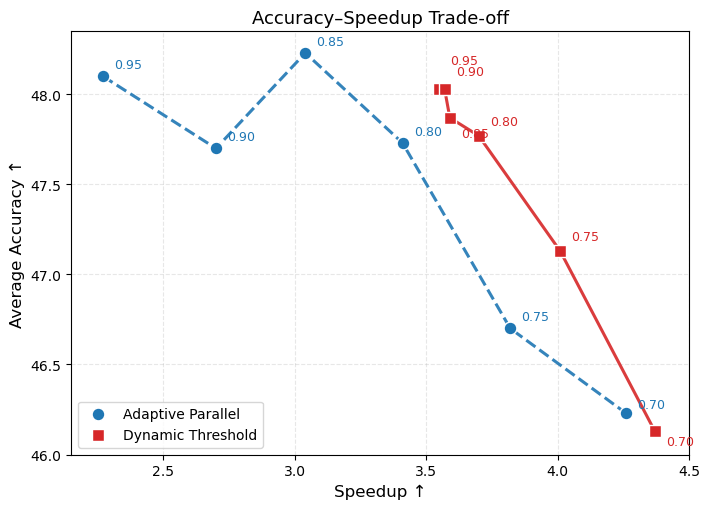